In [1]:
from google.colab import files
uploaded = files.upload()

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import fft, ifft

# Load file
filename = list(uploaded.keys())[0]
fs, signal = wavfile.read(filename)

# If stereo → convert to mono
if len(signal.shape) > 1:
    signal = signal[:,0]

# Normalize
signal = signal / np.max(np.abs(signal))

print("Sampling Rate:", fs)

Saving LJ037-0171.wav to LJ037-0171.wav
Sampling Rate: 22050


In [2]:
frame_size = int(0.025 * fs)   # 25 ms
frame_shift = int(0.010 * fs)  # 10 ms

# Take one frame (you can change index)
start = 1000
frame = signal[start:start+frame_size]

# Apply Hamming window
window = np.hamming(len(frame))
frame = frame * window

In [3]:
# FFT
spectrum = fft(frame)

# Log magnitude spectrum
log_mag = np.log(np.abs(spectrum) + 1e-10)

# Inverse FFT → Cepstrum
cepstrum = np.real(ifft(log_mag))

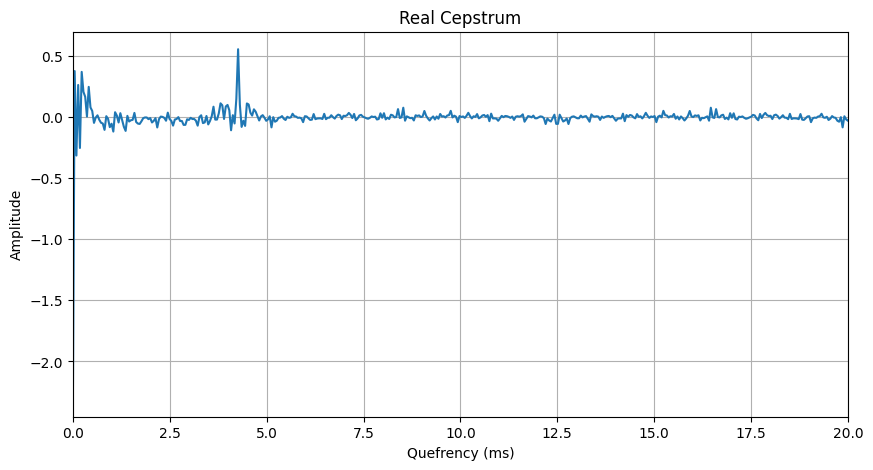

In [4]:
quefrency = np.arange(len(cepstrum)) / fs * 1000  # in ms

plt.figure(figsize=(10,5))
plt.plot(quefrency, cepstrum)
plt.title("Real Cepstrum")
plt.xlabel("Quefrency (ms)")
plt.ylabel("Amplitude")
plt.xlim(0, 20)
plt.grid()
plt.show()

In [5]:
# Define pitch search range (in samples)
min_q = int(fs * 0.005)   # 5 ms
max_q = int(fs * 0.02)    # 20 ms

# Find peak in this range
pitch_index = np.argmax(cepstrum[min_q:max_q]) + min_q

# Pitch period
T0 = pitch_index / fs

# Fundamental frequency
F0 = 1 / T0

print("Pitch Period (T0):", T0, "seconds")
print("Fundamental Frequency (F0):", F0, "Hz")

Pitch Period (T0): 0.008526077097505668 seconds
Fundamental Frequency (F0): 117.2872340425532 Hz


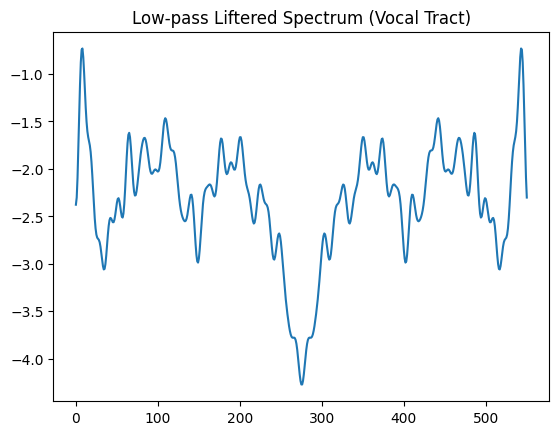

In [6]:
lifter_cutoff = 50  # adjust

low_lifter = np.copy(cepstrum)
low_lifter[lifter_cutoff:] = 0

# Reconstruct
low_spectrum = np.real(fft(low_lifter))

plt.figure()
plt.plot(low_spectrum)
plt.title("Low-pass Liftered Spectrum (Vocal Tract)")
plt.show()

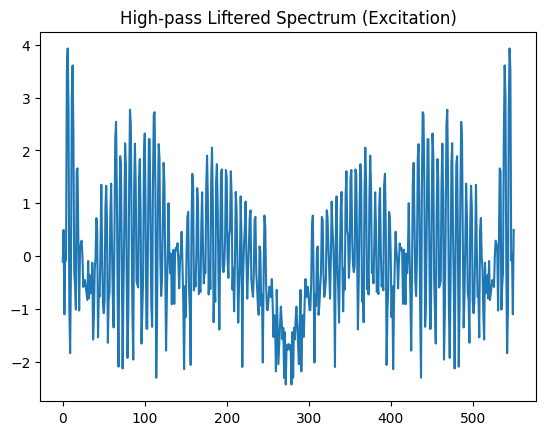

In [7]:
high_lifter = np.copy(cepstrum)
high_lifter[:lifter_cutoff] = 0

# Reconstruct
high_spectrum = np.real(fft(high_lifter))

plt.figure()
plt.plot(high_spectrum)
plt.title("High-pass Liftered Spectrum (Excitation)")
plt.show()

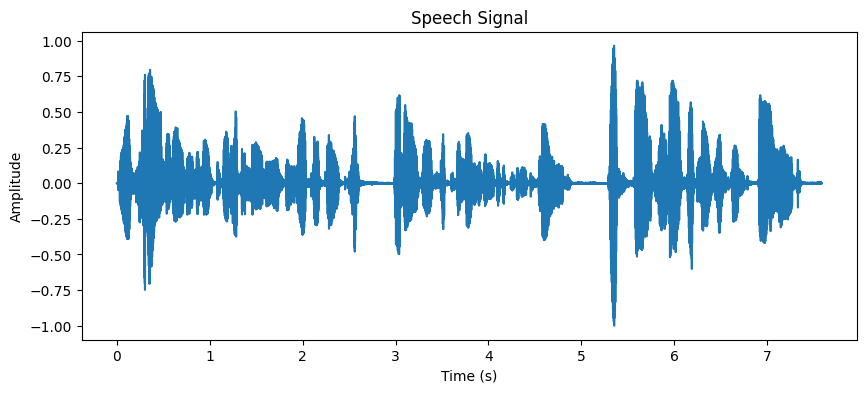

In [8]:
time = np.arange(len(signal)) / fs

plt.figure(figsize=(10,4))
plt.plot(time, signal)
plt.title("Speech Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()